<a href="https://colab.research.google.com/github/Romlabs/1st-Laboratory-Exam/blob/main/Real_Time_Brute_Force_Detection_via_Predictive_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Real-Time Brute-Force Detection via Predictive Machine Learning**

## 1. Importing of necessary dependencies

The code uses `numpy`, `pandas`, `warnings`, `matplotlib` as the main dependencies needed for this code to work.

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from IPython.display import display
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, f1_score, recall_score, average_precision_score
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

### Understanding the Dataset

In [ ]:
df = pd.read_csv("DATASET/cybersecurity_intrusion_data.csv")

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0



Dataset shape:
(9537, 11)

Column names:
['session_id', 'network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access', 'attack_detected']


### Problem Searching

In [ ]:
print("Data types:")
print(df.dtypes)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())

Data types:
session_id              object
network_packet_size      int64
protocol_type           object
login_attempts           int64
session_duration       float64
encryption_used         object
ip_reputation_score    float64
failed_logins            int64
browser_type            object
unusual_time_access      int64
attack_detected          int64
dtype: object

Duplicate rows:
0

Missing values:
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Summary statistics:


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


### Create a Copy

Creating a copy to ensure data safety whenever changes are made.

In [ ]:
clean_df = df.copy()

print("Original rows:", len(df))
print("Working copy rows:", len(clean_df))

Original rows: 9537
Working copy rows: 9537




---



## 2. Data Cleaning

### Feature selection

We will drop non-predictive features before training. `session_id` will be removed. It carries no information for the AI to learn.

In [ ]:
clean_df = clean_df.drop("session_id", axis=1)

In [ ]:
print("\nSummary statistics:")
display(clean_df.head(10))


Summary statistics:


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
5,453,UDP,5,380.471550,AES,0.422486,2,Chrome,1,0
6,815,ICMP,4,728.107165,AES,0.413772,1,Chrome,0,1
7,653,TCP,3,12.599906,DES,0.097719,3,Chrome,1,1
8,406,TCP,2,542.558895,NaN,0.294580,0,Chrome,1,0
9,608,UDP,6,531.944107,NaN,0.424117,1,Chrome,0,0


> The dataset has already been cleaned by the creator of the dataset. But to ensure the good results in the training, we are still required to do data cleaning just in case there are any oddities that exist in the data itself.

### Convert Categorical Data into Numerical Values

In [ ]:
le = LabelEncoder()
clean_df["protocol_type"] = le.fit_transform(clean_df["protocol_type"])
clean_df["browser_type"] = le.fit_transform(clean_df["browser_type"])
clean_df["encryption_used"] = le.fit_transform(clean_df["encryption_used"])

### Remove any possible duplicates

In [ ]:
print(
    "Duplicates before removal:",
    clean_df.duplicated().sum())

clean_df = (
    clean_df
    .drop_duplicates()
    .reset_index(drop=True))

print(
    "Duplicates after removal:",
    clean_df.duplicated().sum())

print(
    "Rows after cleaning:",
    len(clean_df))

Duplicates before removal: 0
Duplicates after removal: 0
Rows after cleaning: 9537


### Checking for outliers

In [ ]:
Q1 = clean_df["session_duration"].quantile(0.25)
Q3 = clean_df["session_duration"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

income_outliers = clean_df[
    (clean_df["session_duration"] < lower_bound) |
    (clean_df["session_duration"] > upper_bound)
]

print("\nPossible outliers:")
display(
    income_outliers[
        [
            "session_duration"
        ]
    ]
)

Q1: 231.95300642419463
Q3: 1105.3806022240433
IQR: 873.4275957998486
Lower bound: -1078.1883872755782
Upper bound: 2415.521995923816

Possible outliers:


,session_duration
27,3286.221728
37,3325.308689
104,2505.190225
116,4282.643311
122,4468.001253
...,...
9447,2881.924724
9462,2539.350521
9469,2460.347045
9481,2533.088427


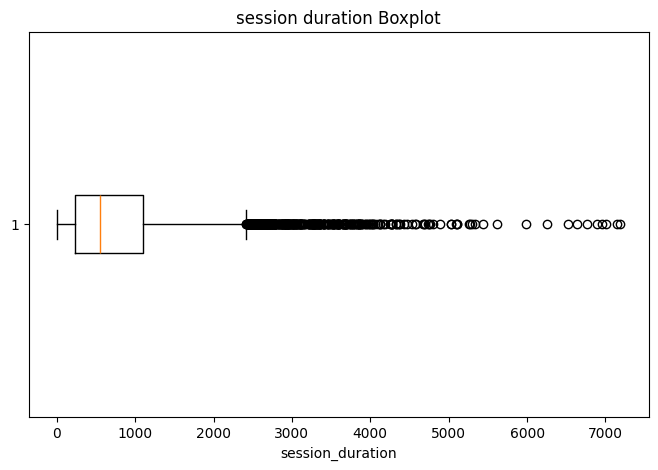

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.boxplot(
    clean_df["session_duration"].dropna(),
    vert=False)

plt.xlabel("session_duration")
plt.title("session duration Boxplot")
plt.show()

### Handling Class Imbalance

In [ ]:
print("Attack value:")
print(clean_df["attack_detected"].value_counts())
print("\nAttack Percentage:")
print(clean_df["attack_detected"]
    .value_counts(normalize=True)
    .mul(100))

Attack value:
attack_detected
0    5273
1    4264
Name: count, dtype: int64

Attack Percentage:
attack_detected
0    55.289923
1    44.710077
Name: proportion, dtype: float64


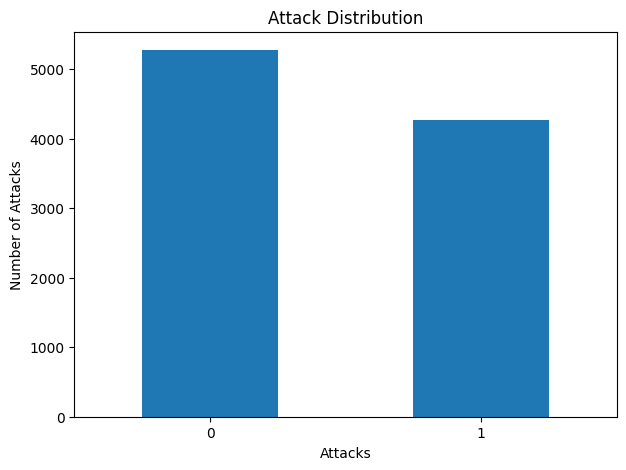

In [ ]:
plt.figure(figsize=(7, 5))
clean_df["attack_detected"].value_counts().plot(
    kind="bar")

plt.xlabel("Attacks")
plt.ylabel("Number of Attacks")
plt.title("Attack Distribution")
plt.xticks(rotation=0)

plt.show()

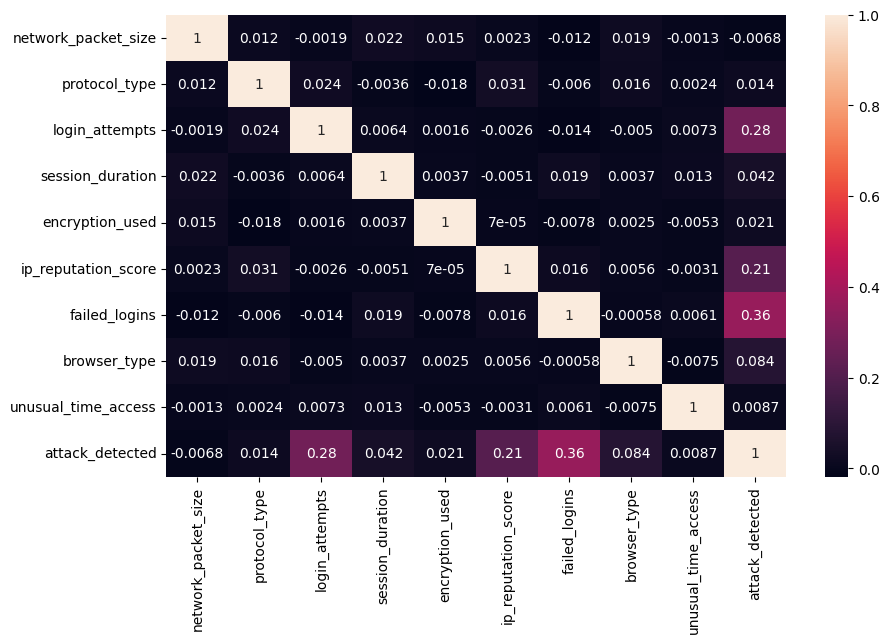

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(clean_df.corr(),annot=True)
plt.show()

## 3. Splitting the Dataset

In [ ]:
# Separate features (X) and target (y)
X = clean_df.drop('attack_detected', axis=1)
y = clean_df['attack_detected']

print("Features")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features
['network_packet_size', 'protocol_type', 'login_attempts', 'session_duration', 'encryption_used', 'ip_reputation_score', 'failed_logins', 'browser_type', 'unusual_time_access']

Target:
attack_detected


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

### SMOTE Resampling

To address the class imbalance in the `attack_detected` column, we'll use SMOTE (Synthetic Minority Over-sampling Technique). This technique oversamples the minority class by creating synthetic samples.

In [ ]:
# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding to categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Shape of X before SMOTE:", X.shape)
print("Shape of y before SMOTE:", y.shape)
print("Shape of X after SMOTE:", X_resampled.shape)
print("Shape of y after SMOTE:", y_resampled.shape)

print("\nDistribution of 'attack_detected' before SMOTE:")
print(y.value_counts())

print("\nDistribution of 'attack_detected' after SMOTE:")
print(y_resampled.value_counts())

Shape of X before SMOTE: (9537, 9)
Shape of y before SMOTE: (9537,)
Shape of X after SMOTE: (10546, 9)
Shape of y after SMOTE: (10546,)

Distribution of 'attack_detected' before SMOTE:
attack_detected
0    5273
1    4264
Name: count, dtype: int64

Distribution of 'attack_detected' after SMOTE:
attack_detected
1    5273
0    5273
Name: count, dtype: int64


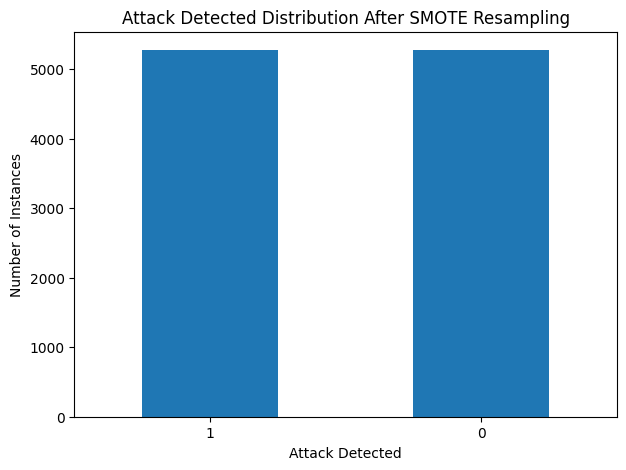

In [ ]:
plt.figure(figsize=(7, 5))
y_resampled.value_counts().plot(
    kind="bar")

plt.xlabel("Attack Detected")
plt.ylabel("Number of Instances")
plt.title("Attack Detected Distribution After SMOTE Resampling")
plt.xticks(rotation=0)

plt.show()

## 4. Classifiers



In [ ]:
models = {
    "Random Forest": RandomForestClassifier(),
}

In [ ]:
ss = StandardScaler()

X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [ ]:
metrics = {
    'Model': [],
    'Precision': [],
    'Recall':[],
    'Accuracy':[]

}

pr_auc = average_precision_score(y_test, y_pred)

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    metrics['Model'].append(name)
    metrics['Accuracy'].append(acc * 100)
    metrics['Precision'].append(precision * 100)
    metrics['Recall'].append(recall * 100)
    print(f"Model: {name}")
    print(f"Accuracy: {acc*100}")
    print(f"PR-AUC: {pr_auc*100}")
    print(f"Precision: {precision*100}")
    print(f"F1 Score: {f1*100}")
    print(f"Recall: {recall*100}")
    print("-" * 30)

Model: Random Forest
Accuracy: 88.52201257861635
PR-AUC: 85.46753842032437
Precision: 99.53125
F1 Score: 85.3315472203617
Recall: 74.67760844079719
------------------------------


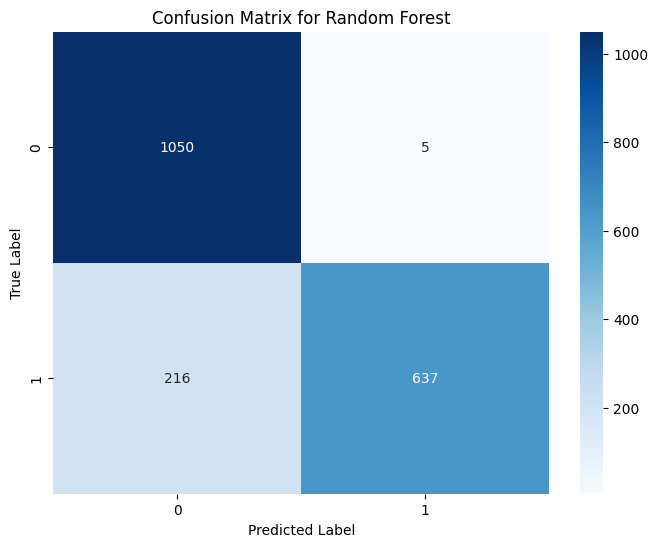

In [ ]:
accuracy_results={}
for name,clf in models.items():
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    accuracy_results[name]=accuracy
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()